In [1]:
import os
import zipfile
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import zipfile
from google.colab import drive

# Path to the zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/validation_dataset.zip'

# Extract path (where you want to extract the contents)
extract_path = '/content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [5]:
# Define the paths for the training and validation data
train_path = '/content/train_dataset'
val_path = '/content/validation_dataset'
test_path = '/content/test_dataset'

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define paths and constants
train_path = '/content/train_dataset'
val_path = '/content/validation_dataset'
test_path = '/content/test_dataset'

batch_size = 64

# Create ImageDataGenerators with data augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),  # VGG16 input size
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 16000 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.


In [7]:
# Load pre-trained VGG16 model without top layers
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the pre-trained layers
for layer in vgg16_base.layers:
    layer.trainable = False

# Add custom top layers for classification
x = Flatten()(vgg16_base.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

# Create the model
model = Model(inputs=vgg16_base.input, outputs=output)

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(lr=0.001),
              metrics=['accuracy'])

model.summary()


58889256/58889256 [==============================] - 2s 0us/step


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [9]:
# Define callbacks
reduce_lr = ReduceLROnPlateau(factor=0.1, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[reduce_lr, early_stop]
)


Epoch 1/10
250/250 [==============================] - 246s 982ms/step - loss: 1.0097 - accuracy: 0.6110 - val_loss: 0.3393 - val_accuracy: 0.9560 - lr: 0.0010
Epoch 2/10
250/250 [==============================] - 245s 979ms/step - loss: 0.9879 - accuracy: 0.6108 - val_loss: 0.1952 - val_accuracy: 0.9600 - lr: 0.0010
Epoch 3/10
250/250 [==============================] - 246s 982ms/step - loss: 0.9304 - accuracy: 0.6343 - val_loss: 0.1757 - val_accuracy: 0.9760 - lr: 0.0010
Epoch 4/10
250/250 [==============================] - 246s 985ms/step - loss: 0.8879 - accuracy: 0.6504 - val_loss: 0.1566 - val_accuracy: 0.9740 - lr: 0.0010
Epoch 5/10
250/250 [==============================] - 244s 976ms/step - loss: 0.8814 - accuracy: 0.6532 - val_loss: 0.1241 - val_accuracy: 0.9775 - lr: 0.0010
Epoch 6/10
250/250 [==============================] - 245s 982ms/step - loss: 0.8645 - accuracy: 0.6543 - val_loss: 0.1269 - val_accuracy: 0.9755 - lr: 0.0010
Epoch 7/10
250/250 [==========================

In [15]:
val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

evaluation_results = model.evaluate(val_gen, steps=val_gen.samples // batch_size)

print('Validaion Loss:', evaluation_results[0])
print('Validaion Accuracy:', evaluation_results[1])



Found 2000 images belonging to 10 classes.
31/31 [==============================] - 8s 264ms/step - loss: 0.1039 - accuracy: 0.9798
Validaion Loss: 0.1039254292845726
Validaion Accuracy: 0.9798387289047241


In [14]:
test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)


evaluation_results = model.evaluate(test_gen, steps=test_gen.samples // batch_size)

print('Test Loss:', evaluation_results[0])
print('Test Accuracy:', evaluation_results[1])


Found 2000 images belonging to 10 classes.
31/31 [==============================] - 8s 259ms/step - loss: 0.0893 - accuracy: 0.9854
Test Loss: 0.08930759876966476
Test Accuracy: 0.9853830933570862


In [16]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_gen)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


32/32 [==============================] - 9s 265ms/step - loss: 0.0895 - accuracy: 0.9855
Test Loss: 0.0895
Test Accuracy: 0.9855


In [17]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(val_gen)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')


32/32 [==============================] - 8s 252ms/step - loss: 0.1042 - accuracy: 0.9800
Validation Loss: 0.1042
Validation Accuracy: 0.9800


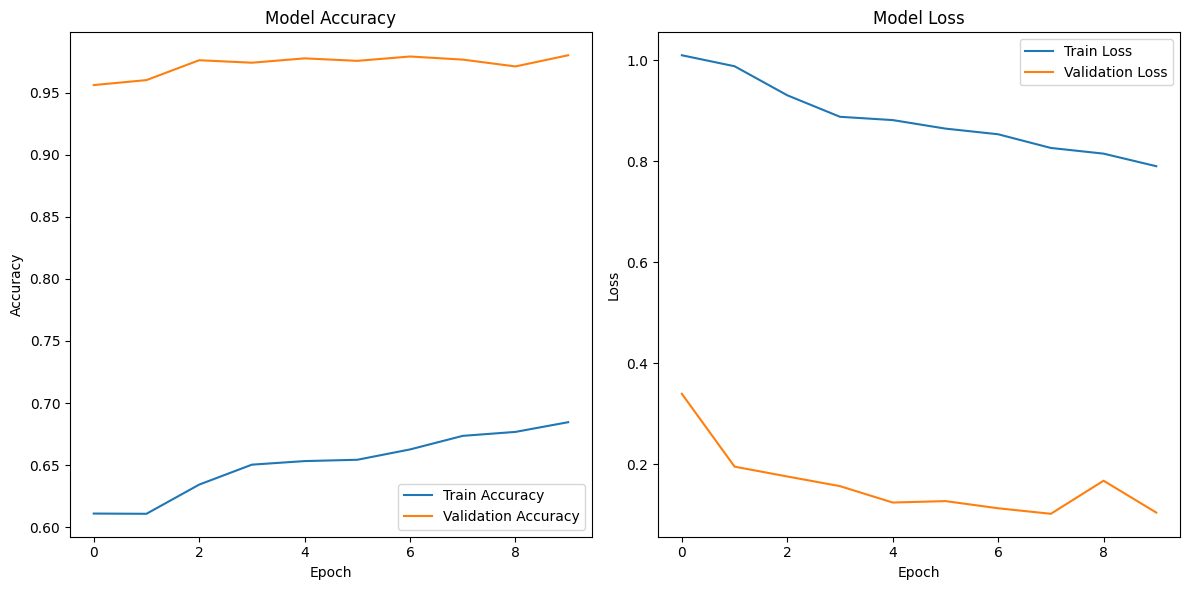

In [18]:

# Plot training history
def plot_training_history(history):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)